# 06_error_analysis — Diagnóstico de Errores y Estrategia Híbrida

**Objetivo:** Entender *por qué* y *dónde* fallan nuestros modelos para diseñar una estrategia híbrida efectiva.

**Preguntas Clave:**
1. ¿En qué casos acierta BETO y fallan las reglas (y viceversa)?
2. ¿Cuántos "falsos positivos" de las reglas son realmente aciertos (errores de anotación)?
3. ¿Existe un patrón léxico claro en los errores de BETO?

**Inputs:**
- Modelo BETO entrenado (`data/checkpoints/beto/checkpoint-189`)
- Dataset Dev Full (`dev_full.csv`)
- Señal Clínica/Reglas (`dataset_with_clinical_signal_flag.csv`)


In [1]:
# ===============================================================
# Setup: Imports y configuración
# ===============================================================
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from datasets import Dataset
from sklearn.metrics import confusion_matrix, classification_report
import torch

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Importar utilidades compartidas
try:
    from utils_shared import setup_paths, load_splits, calculate_metrics
    paths = setup_paths()
    DATA_PATH = paths['DATA_PATH']
    SPLITS_PATH = paths['SPLITS_PATH']
    FIGS_PATH = paths['FIGS_PATH']
    print("[OK] Usando utils_shared.py")
except ImportError:
    print("[ERROR] No se encontró utils_shared.py")
    raise

/Users/manuelnunez/Projects/psych-phenotyping-paraguay/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[OK] Usando utils_shared.py


## 1) Cargar Datos y Modelo

In [2]:
# 1. Cargar Dev Set
df_base, _, dev_idx, _ = load_splits(SPLITS_PATH)
df_dev = df_base.set_index('row_id').loc[dev_idx].reset_index()

# [FIX] Limpiar NaNs en texto para evitar error en Tokenizer
nan_count = df_dev['texto'].isna().sum()
if nan_count > 0:
    print(f"⚠️ Se encontraron {nan_count} valores nulos en 'texto'. Reemplazando por string vacío.")
    df_dev['texto'] = df_dev['texto'].fillna("").astype(str)

print(f"Dataset Dev: {len(df_dev)} casos")

# 2. Cargar Metadata de Reglas (Signal Flag)
df_rules = pd.read_csv(DATA_PATH / 'dataset_with_clinical_signal_flag.csv')
# Mapear por row_id
rule_map = df_rules.set_index('row_id')['has_signal'].to_dict()
df_dev['has_signal'] = df_dev['row_id'].map(rule_map)
# Si has_signal es True -> Predicimos la clase positiva (ej: ansiedad/depresion)
# OJO: has_signal solo dice "tiene palabras clave". 
# Para simplificar, asumiremos que si tiene señal, la regla predice la clase target (1).
# Si no tiene señal, predice la clase control (0).
df_dev['has_signal_int'] = df_dev['has_signal'].astype(int)

# 3. Cargar Modelo BETO
checkpoint_path = DATA_PATH / 'checkpoints/beto/checkpoint-189' # Ajustar si es necesario
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cargando modelo desde: {checkpoint_path}")

tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_path).to(device)
print("Modelo cargado correctamente.")

⚠️ Se encontraron 1 valores nulos en 'texto'. Reemplazando por string vacío.
Dataset Dev: 627 casos
Cargando modelo desde: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/checkpoints/beto/checkpoint-189
Modelo cargado correctamente.


## 2) Inferencia con BETO en Dev Set

In [3]:
# Preprocesar para el modelo
def tokenize_function(examples):
    return tokenizer(examples["texto"], padding="max_length", truncation=True, max_length=512)

ds_dev = Dataset.from_pandas(df_dev[['texto']])
tokenized_dev = ds_dev.map(tokenize_function, batched=True)

# Trainer para predicción
trainer = Trainer(model=model)
preds_output = trainer.predict(tokenized_dev)
y_preds_logits = preds_output.predictions

# [RESEARCH] Softmax for Uncertainty/Comorbidity Analysis
import torch.nn.functional as F
probs = F.softmax(torch.tensor(y_preds_logits), dim=1).numpy()
df_dev['prob_depresion'] = probs[:, 0]
df_dev['prob_ansiedad'] = probs[:, 1]
df_dev['beto_pred'] = np.argmax(y_preds_logits, axis=1)

# Define "Ambiguity" (Comorbidity Proxy)
df_dev['ambiguo'] = np.abs(df_dev['prob_ansiedad'] - 0.5) < 0.15

# Label mapping
label2id = {'depresion': 0, 'ansiedad': 1}
id2label = {v: k for k, v in label2id.items()}
df_dev['target'] = df_dev['etiqueta'].map(label2id)

# [RESEARCH] Rule-based patterns (Regex fallback)
import re
neg_patterns = r"\b(no|niega|negativos|sin|ausencia|nunca|nada)\b"
unc_patterns = r"\b(parece|posible|sospecha|impresiona|claro?|aparente)\b"

df_dev['has_negation'] = df_dev['texto'].str.contains(neg_patterns, case=False, regex=True).fillna(False)
df_dev['has_uncertainty'] = df_dev['texto'].str.contains(unc_patterns, case=False, regex=True).fillna(False)

print("Inferencia y análisis léxico completado.")


Map: 100%|██████████| 627/627 [00:00<00:00, 4315.03 examples/s]
/Users/manuelnunez/Projects/psych-phenotyping-paraguay/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Inferencia y análisis léxico completado.


/var/folders/25/fy01l91x3gj63g090ghxj7000000gn/T/ipykernel_72314/2818888580.py:33: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_dev['has_negation'] = df_dev['texto'].str.contains(neg_patterns, case=False, regex=True).fillna(False)
/var/folders/25/fy01l91x3gj63g090ghxj7000000gn/T/ipykernel_72314/2818888580.py:34: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_dev['has_uncertainty'] = df_dev['texto'].str.contains(unc_patterns, case=False, regex=True).fillna(False)


Total casos en Dev: 627
Casos Ambiguos (Prob ~50%): 43 (6.9%)

Precisión (Accuracy) según Negación:
has_negation
False    0.943925
True     0.826797
Name: acierto_beto, dtype: float64


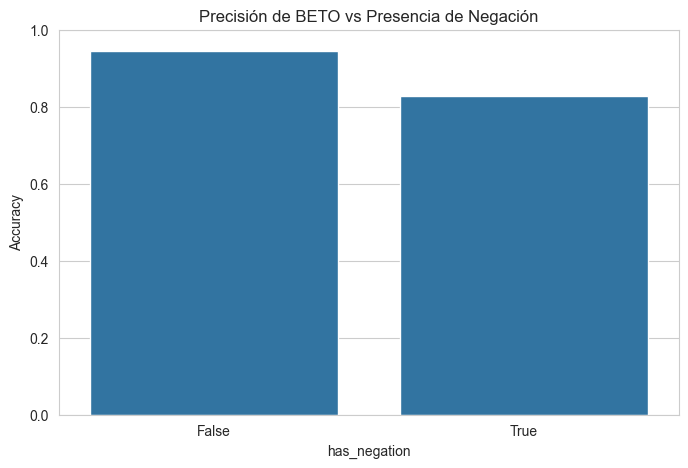

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar casos ambiguos
casos_ambiguos = df_dev[df_dev['ambiguo']]
print(f"Total casos en Dev: {len(df_dev)}")
print(f"Casos Ambiguos (Prob ~50%): {len(casos_ambiguos)} ({len(casos_ambiguos)/len(df_dev)*100:.1f}%)")

# Correlación entre Negación y Error
df_dev['acierto_beto'] = df_dev['target'] == df_dev['beto_pred']
error_by_neg = df_dev.groupby('has_negation')['acierto_beto'].mean()
print("\nPrecisión (Accuracy) según Negación:")
print(error_by_neg)

plt.figure(figsize=(8, 5))
sns.barplot(x=error_by_neg.index.astype(str), y=error_by_neg.values)
plt.title("Precisión de BETO vs Presencia de Negación")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


## 3) Comparación: BETO vs Reglas vs Realidad

Análisis de Coincidencia:


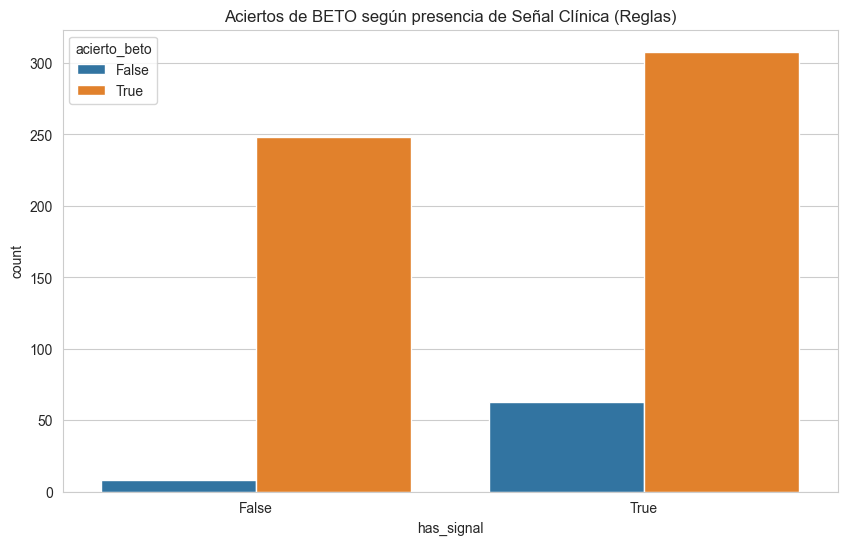

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matriz de Confusión BETO
cm_beto = confusion_matrix(df_dev['target'], df_dev['beto_pred'])
disp_beto = ConfusionMatrixDisplay(confusion_matrix=cm_beto, display_labels=list(label2id.keys()))

# Matriz de Confusión Reglas (Rule-Based)
# Nota: Las reglas de 'has_signal' son binarias (Tiene/No Tiene). 
# Pero tus etiquetas son 'depresion' vs 'ansiedad'. 
# Si has_signal=True, ¿qué predice? 
# ESTO ES UN PUNTO CLAVE: El denoising actual filtra textos SIN señal clínica.
# Asumimos que si has_signal=False -> Es ruido -> El modelo debería predecir... ¿qué?
# En este caso, como es clasificación binaria Depresión/Ansiedad, 'has_signal' no distingue entre ellas.
# 'has_signal' distingue entre 'Enfermo' vs 'Sano/Ruido' O simplemente 'Texto Útil' vs 'Inútil'.
# 
# REVISIÓN: Tu tarea es clasificar entre Depresión y Ansiedad.
# El Denoising elimina textos que NO hablan de ningun síntoma.
# Por tanto, el análisis de error de reglas debe enfocarse en:
# ¿El texto ELIMINADO por reglas (signal=False) tenía etiqueta real?
# Pero en tu dev set, asumo que TODO es relevante? O hay ruido?

print("Análisis de Coincidencia:")
df_dev['acierto_beto'] = df_dev['target'] == df_dev['beto_pred']

# Verificamos si la señal (Denoising) correlaciona con el acierto de BETO
sns.countplot(data=df_dev, x='has_signal', hue='acierto_beto')
plt.title("Aciertos de BETO según presencia de Señal Clínica (Reglas)")
plt.show()

## 4) Inspección de Errores

Veamos los textos donde BETO falla pero las reglas dicen que hay señal.

In [6]:
errores_beto = df_dev[~df_dev['acierto_beto']]
print(f"Total Errores BETO: {len(errores_beto)}")

print("\nEjemplos de errores con Señal Clínica Fuerte (Rule=True):")
for i, row in errores_beto[errores_beto['has_signal'] == True].head(5).iterrows():
    print(f"--- ID: {row['row_id']} ---")
    print(f"Texto: {row['texto'][:200]}...")
    print(f"Real: {row['etiqueta']} | Pred: {id2label[row['beto_pred']]}")
    print("")

Total Errores BETO: 71

Ejemplos de errores con Señal Clínica Fuerte (Rule=True):
--- ID: 75 ---
Texto: Paciente acude en silla de ruedas. Abordable y colaboradora. Realiza Paciente acude en silla de ruedas. Realiza contacto visual. Conductualmente estable. Atiende y comprende. Humor ansioso, afecto aco...
Real: ansiedad | Pred: depresion

--- ID: 80 ---
Texto: paciente acude sin cita, consulta con la dra claudia samudio. refiere despertares precoces, se despierta a las 2am, refiere que dormia mejor con la quetiapina, pero no podia comprarla cuando hizo falt...
Real: ansiedad | Pred: depresion

--- ID: 87 ---
Texto: MC: Control evolutivo MC: Control evolutivo APP Hace 6 meses sufre ACV dejando secuelas de hemiparesia lado izquierdo MC: Control evolutivo APP Hace 6 meses sufre ACV dejando secuelas de hemiparesia l...
Real: ansiedad | Pred: depresion

--- ID: 112 ---
Texto: MC: no mejoro de la ansiedad, estoy peor MC: no mejoro de la ansiedad, estoy peor FXT 20 2 0 0 QTP 100 0 0 1/2 MC: 

## 5) Análisis Corpus-Driven de Falsos Negativos (Ansiedad -> Depresión)

**Objetivo:** Responder a la Pregunta 3: *¿Existe un patrón léxico claro en los errores de BETO?*
Identificaremos términos que aparecen frecuentemente en los casos de **Ansiedad** que el modelo clasificó erróneamente como **Depresión**, pero que NO están en las predicciones correctas de Ansiedad.
Estos términos son candidatos para ser agregados a `Concept_PY`.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 1. Definir Grupos
# FN_Ansiedad: Real=Ansiedad (1), Pred=Depresion (0)
# TP_Ansiedad: Real=Ansiedad (1), Pred=Ansiedad (1) (Linea base de cómo se ve la ansiedad "fácil")
fn_ansiedad = df_dev[(df_dev['target'] == 1) & (df_dev['beto_pred'] == 0)]
tp_ansiedad = df_dev[(df_dev['target'] == 1) & (df_dev['beto_pred'] == 1)]

print(f"Falsos Negativos (Ansiedad perdida): {len(fn_ansiedad)}")
print(f"Verdaderos Positivos (Ansiedad detectada): {len(tp_ansiedad)}")

# 2. Función para extraer N-gramas frecuentes
def get_top_ngrams(corpus, n=1, top_k=20, stop_words=None):
    if len(corpus) == 0:
        return pd.Series()
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stop_words).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq, columns=['term', 'count']).set_index('term').head(top_k)

# Stop words básicas en español (se puede mejorar)
my_stop_words = ['de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'se', 'del', 'las', 'un', 'por', 'con', 'no', 'una', 'su', 'para', 'es', 'al', 'lo', 'como', 'mas', 'pero', 'sus', 'le', 'ya', 'o', 'fue', 'este', 'ha', 'me', 'si', 'sin', 'sobre', 'tambien', 'me', 'hasta', 'son', 'dos', 'entre', 'esta', 'ese', 'eso', 'mis', 'mi', 'muy', 'nos', 'ni', 'tu', 'te', 'ti']

# 3. Extracción de Términos
print("\n--- Top 20 Unigramas en Falsos Negativos ---")
top_uni_fn = get_top_ngrams(fn_ansiedad['texto'], n=1, top_k=30, stop_words=my_stop_words)
print(top_uni_fn)

print("\n--- Top 20 Bigramas en Falsos Negativos ---")
top_bi_fn = get_top_ngrams(fn_ansiedad['texto'], n=2, top_k=30, stop_words=my_stop_words)
print(top_bi_fn)

# 4. Comparación (Distintividad)
# Buscamos términos que son comunes en FN pero RAROS en TP (o simplemente muy frecuentes en FN y ausentes en reglas)
# Simplemente mostramos lado a lado para inspección manual rapida, o calculamos ratio

top_uni_tp = get_top_ngrams(tp_ansiedad['texto'], n=1, top_k=100, stop_words=my_stop_words)

# Calcular "Risk Ratio" simple: Freq_FN / Freq_TP (normalizado)
# Un término con alto riesgo es aquel que aparece mucho cuando FALLAMOS.
df_compare = top_uni_fn.copy()
df_compare['count_tp'] = 0
for term in df_compare.index:
    if term in top_uni_tp.index:
        df_compare.at[term, 'count_tp'] = top_uni_tp.at[term, 'count']
    else:
        df_compare.at[term, 'count_tp'] = 0 # No aparece en los top de aciertos

# Normalizar
df_compare['freq_fn'] = df_compare['count'] / len(fn_ansiedad)
df_compare['freq_tp'] = df_compare['count_tp'] / len(tp_ansiedad)
df_compare['distinctiveness'] = df_compare['freq_fn'] - df_compare['freq_tp']

print("\n--- Términos Distintivos en Errores (Cuadro 5 Candidato) ---")
print(df_compare.sort_values('distinctiveness', ascending=False)[['count', 'count_tp', 'distinctiveness']].head(15))

# Bigramas distintivos
top_bi_tp = get_top_ngrams(tp_ansiedad['texto'], n=2, top_k=100, stop_words=my_stop_words)
df_compare_bi = top_bi_fn.copy()
df_compare_bi['count_tp'] = 0
for term in df_compare_bi.index:
    if term in top_bi_tp.index:
        df_compare_bi.at[term, 'count_tp'] = top_bi_tp.at[term, 'count']

df_compare_bi['freq_fn'] = df_compare_bi['count'] / len(fn_ansiedad)
df_compare_bi['freq_tp'] = df_compare_bi['count_tp'] / len(tp_ansiedad)
df_compare_bi['distinctiveness'] = df_compare_bi['freq_fn'] - df_compare_bi['freq_tp']

print("\n--- Bigramas Distintivos en Errores ---")
print(df_compare_bi.sort_values('distinctiveness', ascending=False)[['count', 'count_tp', 'distinctiveness']].head(15))

Falsos Negativos (Ansiedad perdida): 60
Verdaderos Positivos (Ansiedad detectada): 225

--- Top 20 Unigramas en Falsos Negativos ---
            count
term             
refiere       388
años          193
hace          175
acude         158
medicacion    158
paciente      150
bien          149
control       144
10            111
20             99
sentirse       93
edad           91
desde          84
duerme         77
mejor          76
tiene          76
niega          76
comenta        74
crisis         74
ansiedad       72
peso           70
hijo           70
pulso          68
mc             68
fxt            66
consulta       63
estar          62
clonazepam     60
clinico        57
cnz            56

--- Top 20 Bigramas en Falsos Negativos ---
                        count
term                         
refiere sentirse           80
acude control              53
fxt 20                     52
desde hace                 50
hace meses                 46
duerme bien                45
lado i